# Pneumonia Classification from Chest X-rays

**Computer Vision Assignment 2

Goal: Improve a baseline CNN to maximise accuracy, precision, and recall when classifying chest X-ray images as NORMAL or PNEUMONIA.

Dataset: Chest X-ray images train/test split provided

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Check GPU availability
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [5]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling
from tensorflow.keras.optimizers import Adam

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [6]:
# Dataset paths - UPDATE THESE to match your Google Drive structure
TRAIN_DIR = '/content/drive/MyDrive/Colab Notebooks/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/Colab Notebooks/chest_xray/test'
# Hyperparameters (from lecturer's baseline script)
BATCH_SIZE = 12
EPOCHS = 8
IMG_HEIGHT = 128
IMG_WIDTH  = 128
IMG_CHANNELS = 3

In [7]:
# Load training data with 80/20 train/val split
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    seed=123,
    validation_split=0.2,
    subset='both',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

# Load test data
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    seed=None,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Class names:', class_names)
print('Number of classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class names: ['BACTERIAL', 'NORMAL', 'VIRAL']
Number of classes: 3


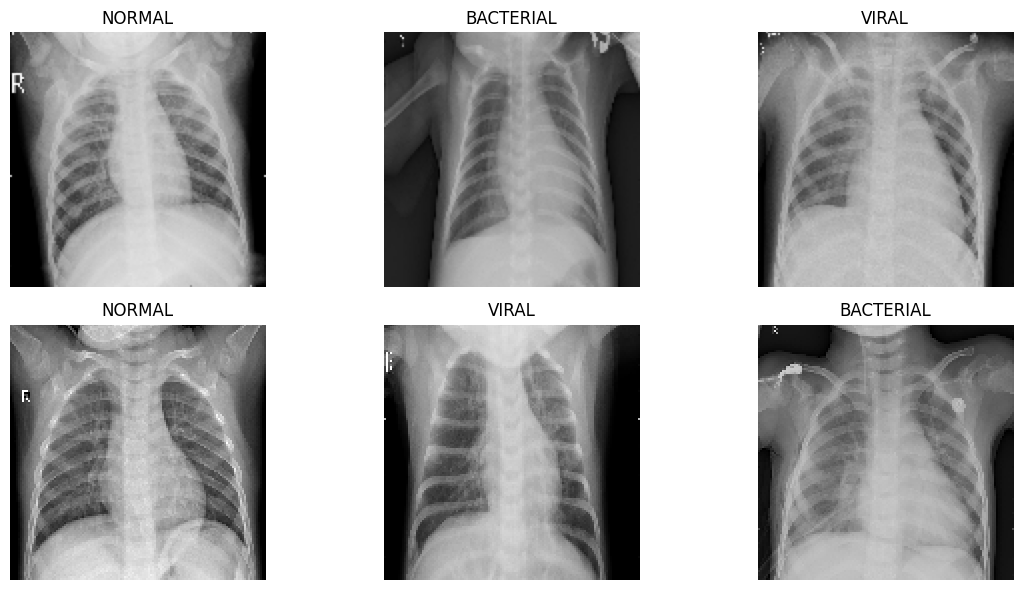

In [8]:
# Display a few sample images from the training set
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i].numpy()])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Build the baseline CNN
model = Sequential([
    Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,227,651 (12.31 MB)

 Trainable params: 3,227,651 (12.31 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train and measure training time
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

training_time = time.time() - start_time
print(f'\nTraining completed in {training_time:.1f} seconds ({training_time/60:.1f} minutes)')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.6933 - loss: 0.6990 - val_accuracy: 0.7673 - val_loss: 0.5470
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 144s 399ms/step - accuracy: 0.7807 - loss: 0.5291 - val_accuracy: 0.7645 - val_loss: 0.5553
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 132s 365ms/step - accuracy: 0.7991 - loss: 0.4812 - val_accuracy: 0.7830 - val_loss: 0.5151
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 147s 406ms/step - accuracy: 0.8127 - loss: 0.4433 - val_accuracy: 0.7793 - val_loss: 0.5094
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 140s 386ms/step - accuracy: 0.8229 - loss: 0.4110 - val_accuracy: 0.7775 - val_loss: 0.5049
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 138s 375ms/step - accuracy: 0.8427 - loss: 0.3636 - val_accuracy: 0.7729 - val_loss: 0.5278
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 140s 367ms/step - accuracy: 0.8672 - loss: 0.3160 - val_accuracy: 0.7710 - val_loss: 0.5930
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 145s 377ms/step - accuracy: 0.8911 - loss: 0.26

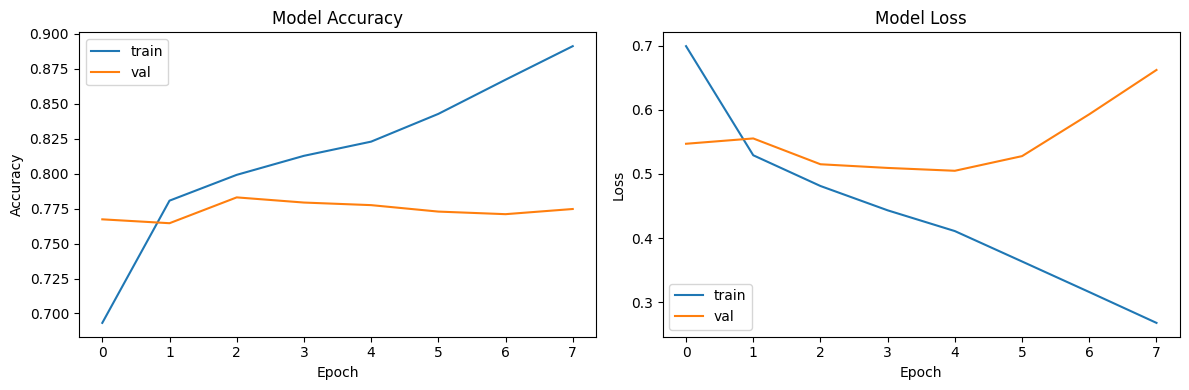

In [11]:
# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Collect all predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [13]:
# Overall test accuracy
test_accuracy = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print()

Test Accuracy: 0.7689 (76.89%)



In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Per-class precision, recall, F1
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Classification Report:
              precision    recall  f1-score   support

   BACTERIAL     0.7162    0.8641    0.7833       184
      NORMAL     0.9224    0.8770    0.8992       122
       VIRAL     0.7071    0.5344    0.6087       131

    accuracy                         0.7689       437
   macro avg     0.7819    0.7585    0.7637       437
weighted avg     0.7710    0.7689    0.7633       437



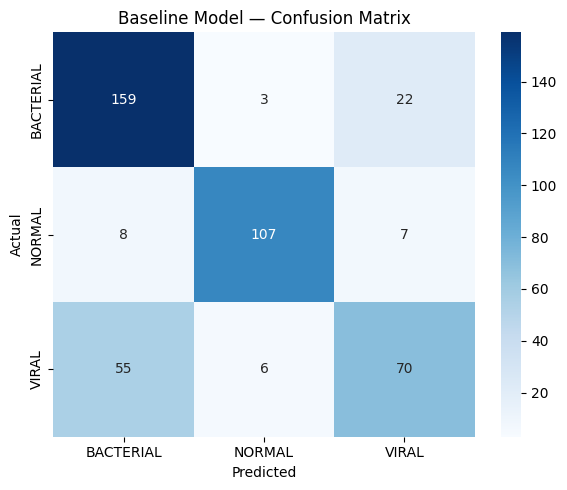

In [16]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

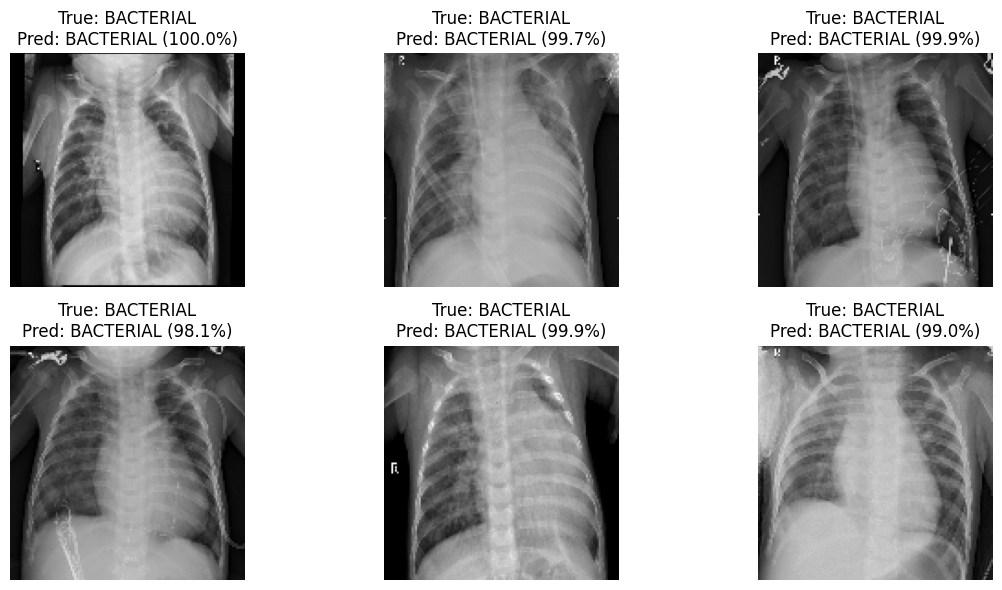

In [17]:
# Show predictions on a few test images
test_batch = test_ds.take(1)
plt.figure(figsize=(12, 6))
for images, labels in test_batch:
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))

        # Make prediction
        prediction = model.predict(tf.expand_dims(images[i], 0), verbose=0)
        pred_class = class_names[np.argmax(prediction)]
        true_class = class_names[labels[i].numpy()]
        confidence = 100 * np.max(prediction)

        plt.title(f'True: {true_class}\nPred: {pred_class} ({confidence:.1f}%)')
        plt.axis('off')
plt.tight_layout()
plt.show()

In [18]:
# ============================================
# EXPERIMENT 1: Data Augmentation
# ============================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

model_aug = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_aug.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

print("Training model WITH data augmentation...")
history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Evaluate
y_true_aug = []
y_pred_aug = []
for images, labels in test_ds:
    preds = model_aug.predict(images, verbose=0)
    y_true_aug.extend(labels.numpy())
    y_pred_aug.extend(np.argmax(preds, axis=1))

y_true_aug = np.array(y_true_aug)
y_pred_aug = np.array(y_pred_aug)

aug_accuracy = (y_true_aug == y_pred_aug).mean()
print(f'\nAugmented Model Accuracy: {aug_accuracy:.4f} ({aug_accuracy*100:.2f}%)')
print(classification_report(y_true_aug, y_pred_aug,
      target_names=class_names, digits=4))

Training model WITH data augmentation...
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


362/362 ━━━━━━━━━━━━━━━━━━━━ 166s 434ms/step - accuracy: 0.6402 - loss: 0.8185 - val_accuracy: 0.7091 - val_loss: 0.6567
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 195s 417ms/step - accuracy: 0.7145 - loss: 0.6853 - val_accuracy: 0.7285 - val_loss: 0.6212
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 148s 409ms/step - accuracy: 0.7276 - loss: 0.6360 - val_accuracy: 0.7442 - val_loss: 0.5927
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 153s 423ms/step - accuracy: 0.7502 - loss: 0.5963 - val_accuracy: 0.7442 - val_loss: 0.5799
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 149s 409ms/step - accuracy: 0.7359 - loss: 0.6178 - val_accuracy: 0.7285 - val_loss: 0.6205
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 151s 416ms/step - accuracy: 0.7606 - loss: 0.5703 - val_accuracy: 0.7747 - val_loss: 0.5475
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 204s 422ms/step - accuracy: 0.7657 - loss: 0.5515 - val_accuracy: 0.7701 - val_loss: 0.5519
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 201s 420ms/step - accuracy: 0.7687 - loss: 0.5400 - va

Data augmentation was applied to the  reduce overfitting. Random horizontal flips rotations, zooms and contrast adjustments were added as a first layers of the model. The results are mixed - NORMAL recall improved from 87% to 95% and BACTERIAL from 86% to 90%, but VIRAL recall dropped from 53% to 28%. Overall accuracy fell slightly from 76.89% to 73.23%.

In [19]:
# ============================================
# EXPERIMENT 2: Class Weighting
# ============================================
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to fix VIRAL recall problem
all_labels = []
for images, labels in train_ds:
    all_labels.extend(labels.numpy())
all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

# Same model as experiment 1 but with class weights
model_weighted = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_weighted.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

print("Training WITH class weights...")
history_weighted = model_weighted.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict
)

# Evaluate
y_true_w = []
y_pred_w = []
for images, labels in test_ds:
    preds = model_weighted.predict(images, verbose=0)
    y_true_w.extend(labels.numpy())
    y_pred_w.extend(np.argmax(preds, axis=1))

y_true_w = np.array(y_true_w)
y_pred_w = np.array(y_pred_w)

w_accuracy = (y_true_w == y_pred_w).mean()
print(f'\nWeighted Model Accuracy: {w_accuracy:.4f} ({w_accuracy*100:.2f}%)')
print(classification_report(y_true_w, y_pred_w,
      target_names=class_names, digits=4))

Class weights: {0: np.float64(0.6925411276153969), 1: np.float64(1.240629470672389), 2: np.float64(1.3333333333333333)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training WITH class weights...
Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 156s 422ms/step - accuracy: 0.5514 - loss: 0.9126 - val_accuracy: 0.6953 - val_loss: 0.6888
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 148s 408ms/step - accuracy: 0.6882 - loss: 0.7132 - val_accuracy: 0.7101 - val_loss: 0.6687
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 149s 412ms/step - accuracy: 0.7154 - loss: 0.6504 - val_accuracy: 0.7258 - val_loss: 0.6215
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 176s 485ms/step - accuracy: 0.7299 - loss: 0.6198 - val_accuracy: 0.7572 - val_loss: 0.5937
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 164s 451ms/step - accuracy: 0.7493 - loss: 0.5866 - val_accuracy: 0.7581 - val_loss: 0.5751
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 163s 449ms/step - accuracy: 0.7553 - loss: 0.5745 - val_accuracy: 0.7433 - val_loss: 0.5816
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 157s 434ms/step - accuracy: 0.7571 - loss: 0.5757 - val_accuracy: 0.7664 - val_loss: 0.5420
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 152s 420ms/st

Class weighting improved NORMAL recall to 98% and recovered VIRAL recall to 52%. The model is more balanced but VIRAL recall still needs improvement

In [20]:
# ============================================
# EXPERIMENT 3: Improved Architecture
# ============================================

from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization

model_improved = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(32, (3, 3), activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),  # replaces the Flatten - fewer params, less overfitting
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_improved.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_improved.summary()

# EarlyStopping stops training when val_loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_improved = model_improved.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # more epochs but early stopping will kick in
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

# Evaluate
y_true_i = []
y_pred_i = []
for images, labels in test_ds:
    preds = model_improved.predict(images, verbose=0)
    y_true_i.extend(labels.numpy())
    y_pred_i.extend(np.argmax(preds, axis=1))

y_true_i = np.array(y_true_i)
y_pred_i = np.array(y_pred_i)

print(f'Improved Model Accuracy: {(y_true_i == y_pred_i).mean():.4f}')
print(classification_report(y_true_i, y_pred_i,
      target_names=class_names, digits=4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,939 (499.76 KB)

 Trainable params: 127,491 (498.01 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 313s 853ms/step - accuracy: 0.5796 - loss: 0.8529 - val_accuracy: 0.4700 - val_loss: 3.2630
Epoch 2/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 306s 845ms/step - accuracy: 0.6534 - loss: 0.7698 - val_accuracy: 0.6731 - val_loss: 0.7676
Epoch 3/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 302s 834ms/step - accuracy: 0.6667 - loss: 0.7404 - val_accuracy: 0.2733 - val_loss: 7.0996
Epoch 4/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 310s 855ms/step - accuracy: 0.6739 - loss: 0.7169 - val_accuracy: 0.4774 - val_loss: 1.3849
Epoch 5/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 320s 850ms/step - accuracy: 0.6921 - loss: 0.6948 - val_accuracy: 0.4737 - val_loss: 1.8381
Epoch 6/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 283s 782ms/step - accuracy: 0.6923 - loss: 0.6661 - val_accuracy: 0.4654 - val_loss: 2.6401
Epoch 7/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 338s 825ms/step - accuracy: 0.7018 - loss: 0.6725 - val_accuracy: 0.6260 - val_loss: 0.8768
Improved Model Accuracy: 0.6453
              precision    recall  f1-score 

The improved architecture with GlobalAveragePooling2D performed worse on its own 64.53% showsthe model needs pretrained weights to learn effectively with this architecture